# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need. 

If you have any questions please contact roman.studer@fhnw.ch

###  Team Name and Members
- Student 1: Julian Wehrle
- Student 2: Selma Wirth
- Student 3: Nathan Massicot : [Github](https://github.com/Nathan-massicot "Tooltip on hover")


### Some Guidelines

- You are allowed to use generative models (e.g. ChatGPT, Claude etc.) for code completion or suggestions. However, we require you to perfectly understand and control the code. 
- You are **not** allowed to use the same or similar generative models for providing reflection on the achieved results. __You__ must reflect about what you see and build your own opinion about it.
- You are allowed to create additional python scripts to outsource code snippets to improve readability.

## Project Setup


### 1. Create the virtual environment

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

In [4]:
# imports
import textwrap

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader
)
from tokenizer import tokenize

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# TODO: Add your own imports here, if needed.
import torch.nn as nn
from dotenv import load_dotenv
load_dotenv()

import wandb
wandb.login()

import torch.optim as optim
from tqdm import tqdm

from torchvision import transforms

from nltk.translate.bleu_score import corpus_bleu
import nltk

import matplotlib.pyplot as plt

from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

torch version: 2.12.0
torchvision version: 0.27.0


### 2. Download the dataset
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/ìmages`-folder. Make sure to download all the images and placing them in the folder `data/images/`. 
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

## Dataloader, Tokenizer

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. | 
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. | 
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. | 
| `<unk>`  | 3 | unknown - not available in vocabulary | 

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [5]:
# Transforms

IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            # START - MODIFY / EXTEND THIS PART
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.RandomCrop(IMAGENET_SIZE),                 
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
            transforms.RandomGrayscale(p=0.05),
            # END - MODIFY / EXTEND THIS PART
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def build_test_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [6]:
data_dir = "data/"

MIN_WORD_FREQ = 5
MAX_LEN = 40
BATCH_SIZE = 32

In [7]:
# TODO: POSSIBLY USE YOUR OWN TOKENIZER AND SET IT TO tokenizer=YourTokenizer(...)
# Make sure to build the vocabulary only from training captions to avoid test leakage.

tokenizer = build_tokenizer_from_split(split="train", data_dir = data_dir, min_freq=MIN_WORD_FREQ)

train_loader = create_caption_dataloader(
    split="train", 
    data_dir = data_dir, 
    tokenizer=tokenizer, 
    transform = build_train_transforms(),
    batch_size = BATCH_SIZE, 
    max_len=MAX_LEN, 
    caption_sampling="all")
test_loader = create_caption_dataloader(
    split="test", 
    data_dir = data_dir, 
    tokenizer=tokenizer, 
    transform = build_test_transforms(),
    batch_size = BATCH_SIZE, 
    max_len=MAX_LEN, 
    caption_sampling="random")

images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Number of training examples: {len(train_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))

print(f"Number of test examples: {len(test_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

Vocabulary size: 2,649
Number of training examples: 32,365
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [15, 19, 11, 14, 15, 11, 11, 8, 14, 9, 11, 13, 15, 8, 12, 14, 10, 21, 10, 11, 15, 10, 9, 16, 13, 21, 11, 11, 13, 11, 17, 12]
Number of test examples: 1,618
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [21, 20, 13, 17, 12, 10, 10, 11, 7, 16, 9, 14, 10, 18, 10, 9, 12, 10, 14, 13, 6, 10, 8, 11, 12, 13, 9, 17, 24, 11, 13, 9]


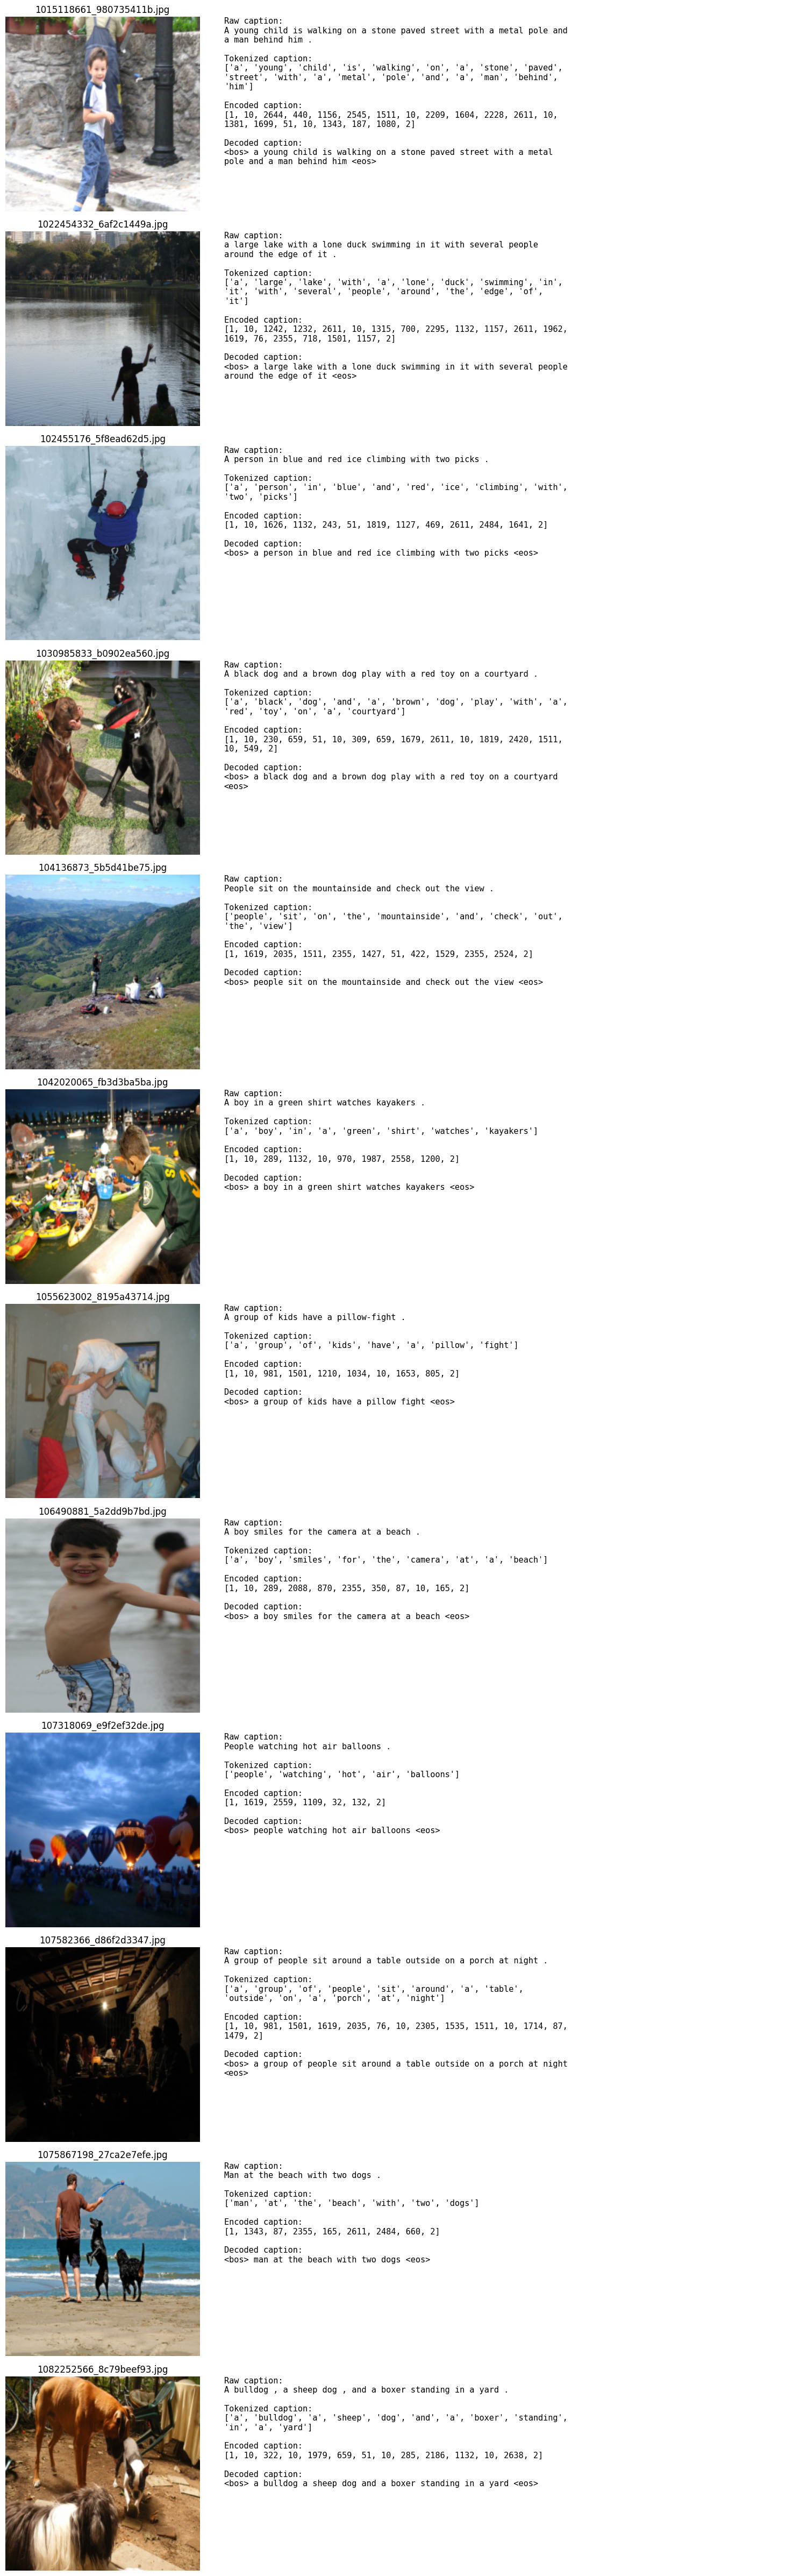

In [8]:
num_examples = 12
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=70)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=70)}",
            f"Decoded caption:\n{textwrap.fill(decoded_caption, width=70)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualization helpers here. This way your model models stay directly comparable.


In [9]:
# Define shared config, helper functions, a fixed evaluation subset, and BLEU computation.
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else: 
    DEVICE = torch.device("cpu")

print("device:", DEVICE)


# further helper functionality:
# ...

device: mps


## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper . Record the training behavior, inspect a few generated captions on held-out images, and report BLEU on your fixed evaluation subset.

In [19]:
ENCODER_DIM = 512
EMBED_DIM = 256
DECODER_DIM = 512
DROPOUT = 0.5
FREEZE_ENCODER = True
NUM_EPOCHS = 20
LEARNING_RATE = 3e-4

In [20]:
class ShowAndTellEncoder(nn.Module):
    def __init__(self, encoder_dim=512, freeze=True):
        super().__init__()  
        resnet = torchvision.models.resnet18(pretrained=True)
        modules = list(resnet.children())[:-1] 
        self.resnet = nn.Sequential(*modules)
        self.fc = nn.Linear(512, encoder_dim)  
        self.relu = nn.ReLU()                  
        self.dropout = nn.Dropout(p=0.5)       
        if freeze:
            for param in self.resnet.parameters():
                param.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.resnet(images)
        features = features.squeeze(-1).squeeze(-1)
        features = self.dropout(self.relu(self.fc(features)))
        return features


class ShowAndTellCaptioner(nn.Module):
    def __init__(self, vocab_size, encoder_dim, embed_dim, decoder_dim, dropout):
        super().__init__() 
        self.encoder = ShowAndTellEncoder(encoder_dim, freeze=FREEZE_ENCODER)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, decoder_dim, batch_first=True)
        self.fc_out = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        image_features = self.encoder(images) 
        h = torch.tanh(self.init_h(image_features)).unsqueeze(0)
        c = torch.tanh(self.init_c(image_features)).unsqueeze(0) 
        embeddings = self.dropout(self.embedding(captions[:, :-1])) 
        outputs, _ = self.lstm(embeddings, (h, c))
        predictions = self.fc_out(outputs)
        return predictions

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        batch_size = images.size(0)
        image_features = self.encoder(images)
        h = torch.tanh(self.init_h(image_features)).unsqueeze(0)
        c = torch.tanh(self.init_c(image_features)).unsqueeze(0)
        input_token = torch.full(
            (batch_size,), 
            tokenizer.bos_idx,      
            dtype=torch.long
        ).to(images.device)
        generated = []
        for _ in range(max_len):
            emb = self.embedding(input_token).unsqueeze(1)
            out, (h, c) = self.lstm(emb, (h, c))
            scores = self.fc_out(out.squeeze(1))
            next_token = scores.argmax(dim=-1)
            generated.append(next_token)
            input_token = next_token
        return torch.stack(generated, dim=1)
    
    @torch.no_grad()
    def generate_beam(self, images: torch.Tensor, beam_size=3, max_len=35) -> list:
        batch_size = images.size(0)
        results = []
        
        for idx in range(batch_size):
            image = images[idx].unsqueeze(0)
            
            image_features = self.encoder(image)
            h = torch.tanh(self.init_h(image_features)).unsqueeze(0)  
            c = torch.tanh(self.init_c(image_features)).unsqueeze(0)
            
            beams = [(0.0, [tokenizer.bos_idx], h, c)]
            completed = []
            
            for _ in range(max_len):
                new_beams = []
                
                for score, tokens, h, c in beams:
                    if tokens[-1] == tokenizer.eos_idx:
                        completed.append((score, tokens))
                        continue
                    
                    input_token = torch.tensor([tokens[-1]], dtype=torch.long).to(images.device)
                    emb = self.embedding(input_token).unsqueeze(1)  
                    
                    out, (h_new, c_new) = self.lstm(emb, (h, c))
                    log_probs = torch.log_softmax(self.fc_out(out.squeeze(1)), dim=-1)
                    
                    top_log_probs, top_tokens = log_probs[0].topk(beam_size)
                    
                    for log_prob, token in zip(top_log_probs, top_tokens):
                        new_score = score + log_prob.item()
                        new_beams.append((
                            new_score,
                            tokens + [token.item()],
                            h_new,
                            c_new
                        ))
                
                if not new_beams:
                    break
                
                beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
            
            for score, tokens, h, c in beams:
                completed.append((score, tokens))
            
            best = sorted(completed, key=lambda x: x[0], reverse=True)[0]
            tokens = best[1]
            
            tokens = tokens[1:]  
            if tokenizer.eos_idx in tokens:
                tokens = tokens[:tokens.index(tokenizer.eos_idx)]
            
            results.append(tokens)
        
        return results 

In [27]:
wandb.init(
    project="image-captioning",
    name="show-and-tell-baseline",
    config={
        "encoder_dim": ENCODER_DIM,
        "embed_dim": EMBED_DIM,
        "decoder_dim": DECODER_DIM,
        "dropout": DROPOUT,
        "freeze_encoder": FREEZE_ENCODER,
        "batch_size": BATCH_SIZE,
        "min_word_freq": MIN_WORD_FREQ,
        "max_len": MAX_LEN,
        "vocab_size": len(tokenizer),
        "learning_rate": LEARNING_RATE,
        "num_epochs": NUM_EPOCHS,
    }
)

epoch,▁█
perplexity,█▁
train_loss,█▁
val_loss,█▁
epoch,2
perplexity,25.06659
train_loss,3.41608
val_loss,3.22154


In [21]:
# Model
model = ShowAndTellCaptioner(
    vocab_size=len(tokenizer),
    encoder_dim=ENCODER_DIM,
    embed_dim=EMBED_DIM,
    decoder_dim=DECODER_DIM,
    dropout=DROPOUT,
).to(DEVICE)

# Sanity check
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     15,578,521
Trainable parameters: 4,402,009


In [22]:
# loss function and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_idx)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

In [ ]:
# training loop
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for images, captions, lengths, image_ids, raw_captions in tqdm(loader, desc="Training"):
        images   = images.to(device)
        captions = captions.to(device)
       
        predictions = model(images, captions) 
        predictions = predictions.reshape(-1, predictions.shape[-1])

        targets     = captions[:, 1:].reshape(-1)
        
        loss = criterion(predictions, targets)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for images, captions, lengths, image_ids, raw_captions in tqdm(loader, desc="Validation"):
            images   = images.to(device)
            captions = captions.to(device)
            
            predictions = model(images, captions)
            predictions = predictions.reshape(-1, predictions.shape[-1])
            targets     = captions[:, 1:].reshape(-1)
            
            loss = criterion(predictions, targets)
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [ ]:
# test one forward pass works
images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))
images   = images.to(DEVICE)
captions = captions.to(DEVICE)

predictions = model(images, captions)
print("predictions shape:", predictions.shape)  

predictions_flat = predictions.reshape(-1, predictions.shape[-1])
targets_flat     = captions[:, 1:].reshape(-1)
loss = criterion(predictions_flat, targets_flat)
print("loss:", loss.item())  

predictions shape: torch.Size([32, 39, 2649])
loss: 7.866146564483643


In [ ]:
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss   = val_epoch(model, test_loader, criterion, DEVICE)
    perplexity = torch.exp(torch.tensor(val_loss)).item()
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | perplexity: {perplexity:.2f}")
    
    wandb.log({
        "train_loss": train_loss,
        "val_loss":   val_loss,
        "perplexity": perplexity,
    }, step=epoch + 1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_sat.pth")
        print(f"  → saved best model")

Validation: 100%|██████████| 51/51 [00:07<00:00,  6.69it/s]


Epoch 1/20 | train_loss: 4.1055 | val_loss: 3.5298 | perplexity: 34.12
  → saved best model


Validation: 100%|██████████| 51/51 [00:07<00:00,  6.93it/s]


Epoch 2/20 | train_loss: 3.4146 | val_loss: 3.2561 | perplexity: 25.95
  → saved best model


Validation: 100%|██████████| 51/51 [00:07<00:00,  6.89it/s]


...

Epoch 18/20 | train_loss: 2.2326 | val_loss: 2.7704 | perplexity: 15.97


Validation: 100%|██████████| 51/51 [00:07<00:00,  6.88it/s]


Epoch 19/20 | train_loss: 2.2047 | val_loss: 2.7767 | perplexity: 16.07


Validation: 100%|██████████| 51/51 [00:07<00:00,  7.00it/s]

Epoch 20/20 | train_loss: 2.1782 | val_loss: 2.7769 | perplexity: 16.07


In [23]:
# load best model
model.load_state_dict(torch.load("best_model_sat.pth", map_location=DEVICE))
model.eval()
print("model loaded")

model loaded


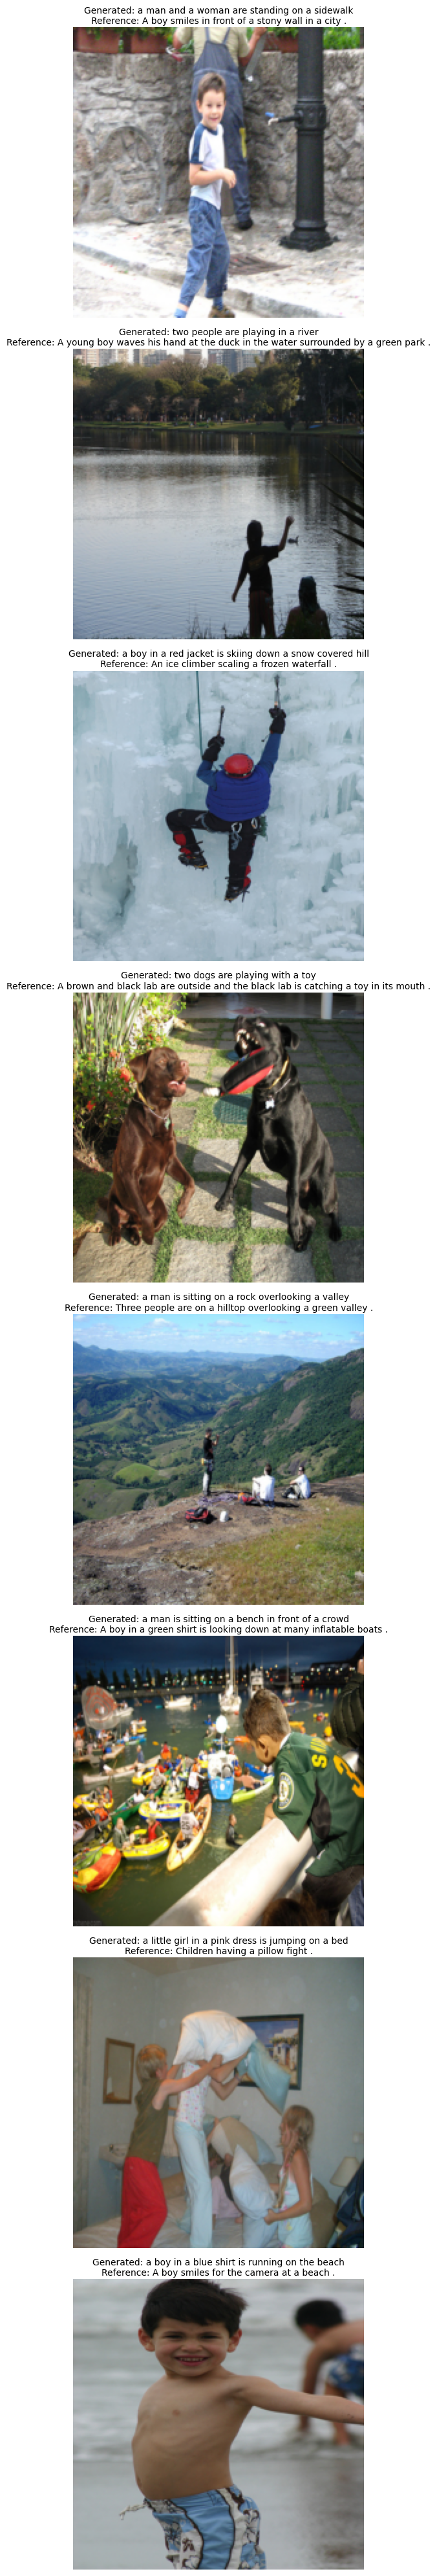

In [ ]:
# generate + display captions on test images
images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    generated = model.generate(images, max_len=35)

fig, axes = plt.subplots(8, 1, figsize=(12, 40))
for i in range(8):
    tokens = generated[i].cpu().tolist()
    if tokenizer.eos_idx in tokens:
        tokens = tokens[:tokens.index(tokenizer.eos_idx)]
    generated_caption = tokenizer.decode(tokens)
    
    img = denormalize_image(images[i].cpu()).permute(1, 2, 0)
    
    axes[i].imshow(img)
    axes[i].set_title(f"Generated: {generated_caption}\nReference: {raw_captions[i]}", 
                      fontsize=10, wrap=True)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# compute BLEU scores
nltk.download('punkt')

references = []
hypotheses = []

model.eval()
with torch.no_grad():
    for images, captions, lengths, image_ids, raw_captions in tqdm(test_loader):
        images = images.to(DEVICE)
        
        generated = model.generate(images, max_len=35)
        
        for i in range(len(images)):
            tokens = generated[i].cpu().tolist()
            if tokenizer.eos_idx in tokens:
                tokens = tokens[:tokens.index(tokenizer.eos_idx)]
            hypothesis = tokenizer.decode(tokens).split()
            
            reference = [raw_captions[i].split()]
            
            references.append(reference)
            hypotheses.append(hypothesis)

bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

wandb.log({
    "bleu1": bleu1,
    "bleu2": bleu2,
    "bleu3": bleu3,
    "bleu4": bleu4,
})
wandb.finish()

[nltk_data] Downloading package punkt to /Users/selma/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
100%|██████████| 51/51 [00:07<00:00,  6.56it/s]


BLEU-1: 0.2296
BLEU-2: 0.1188
BLEU-3: 0.0664
BLEU-4: 0.0365


bleu1,▁
bleu2,▁
bleu3,▁
bleu4,▁
perplexity,█▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
val_loss,█▆▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
bleu1,0.22958
bleu2,0.11878
bleu3,0.06639
bleu4,0.03648


*Training Behavior*
The model was trained for 20 epochs using teacher forcing, Adam optimizer (lr=3e-4), and CrossEntropyLoss with padding masking. As visible in the W&B training curves, training loss decreased steadily from 4.10 to 2.18 across all 20 epochs. Validation loss dropped sharply in the first 8 epochs from 3.53 to 2.77, then plateaued and oscillated between 2.74 and 2.78 for the remaining epochs — a clear overfitting signal. The best model was saved at epoch 17 (val_loss: 2.737). Perplexity followed the same pattern, dropping from ~35 to ~15, meaning the model narrowed its next-word predictions from roughly 35 candidates to 15 on average. Early stopping around epoch 8-10 would have been sufficient given the validation curve behavior.

*Qualitative Analysis*
Generated captions showed the model learned high-level scene understanding — correctly identifying settings (beach, park), subject types (boy, dog, person), and producing grammatically correct sentences. However fine-grained details were frequently wrong: hallucinated attributes ("blue shirt" for a shirtless boy), incorrect actions ("running" instead of "smiling"), and missing the most visually salient element of the image. This is a fundamental limitation of compressing an entire image into a single global feature vector — spatial and fine-grained information is inevitably lost in that bottleneck.

*BLEU Scores and Limitations*
The sharp drop from BLEU-1 to BLEU-4 reflects that while individual words are sometimes correct, longer phrase matches are rare. BLEU has known limitations for captioning: it compares against only one reference caption per image instead of five as in the original paper, penalizes valid synonyms ("child" vs "boy"), and does not reward grammatical correctness or semantic accuracy. The original NIC paper achieved BLEU-1 of 0.63 on Flickr8k using beam search with size 20 and a larger CNN — the gap to our 0.23 is expected given greedy decoding, ResNet18, and the single-reference evaluation setup.

![Training curves](wandb_perplexity.png)
![Training curves](wandb_train_val_loss.png)

## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.


In [ ]:
# TODO Parameters for the Show, Attend and Tell Architecture
ENCODER_DIM = 
EMBED_DIM = 
DECODER_DIM = 
DROPOUT = 
FREEZE_ENCODER = 
ATTENTION_DIM = 

In [ ]:
class ShowAttendTellEncoder(nn.Module):
    def __init__(self, ...):
        # TODO
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO


class AdditiveAttention(nn.Module):
    def __init__(self, ....):
        # TODO
    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
        # encoder_out: (B, num_pixels, encoder_dim)
        # decoder_hidden: (B, decoder_dim)
        # TODO

class ShowAttendTellCaptioner(nn.Module):
    def __init__(self, ...):
        # TODO

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # TODO

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        # TODO

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 2 here and in the following cells.

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 2.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Beam Search

*Hypothesis*: Greedy decoding always picks the single most probable word at each step, which can lead to suboptimal sentences overall. Beam search keeps the k best partial sequences at each step, giving it a better chance of finding a higher quality complete sentence. We expect BLEU scores to improve as beam size increases, but with smaller and smaller gains as k grows larger.

In [ ]:
def evaluate_beam(model, loader, beam_size, device):
    references = []
    hypotheses = []
    
    model.eval()
    with torch.no_grad():
        for images, captions, lengths, image_ids, raw_captions in tqdm(loader, desc=f"Beam k={beam_size}"):
            images = images.to(device)
            generated = model.generate_beam(images, beam_size=beam_size)
            
            for i in range(len(images)):
                hypothesis = tokenizer.decode(generated[i]).split()
                reference  = [raw_captions[i].split()]
                hypotheses.append(hypothesis)
                references.append(reference)
    
    return {
        "bleu1": corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0)),
        "bleu2": corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0)),
        "bleu3": corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0)),
        "bleu4": corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25)),
    }

results = {}
for k in [1, 3, 5, 10]:
    results[k] = evaluate_beam(model, test_loader, beam_size=k, device=DEVICE)
    print(f"Beam k={k}: BLEU-1={results[k]['bleu1']:.4f} BLEU-4={results[k]['bleu4']:.4f}")

Beam k=1: 100%|██████████| 51/51 [00:32<00:00,  1.59it/s]


Beam k=1: BLEU-1=0.2345 BLEU-4=0.0400


Beam k=3: 100%|██████████| 51/51 [02:50<00:00,  3.35s/it]


Beam k=3: BLEU-1=0.2145 BLEU-4=0.0356


Beam k=5: 100%|██████████| 51/51 [08:06<00:00,  9.54s/it]


Beam k=5: BLEU-1=0.2036 BLEU-4=0.0353


Beam k=10: 100%|██████████| 51/51 [36:58<00:00, 43.50s/it]   

Beam k=10: BLEU-1=0.1830 BLEU-4=0.0280


In [25]:
print(f"{'Beam Size':<12} {'BLEU-1':<10} {'BLEU-2':<10} {'BLEU-3':<10} {'BLEU-4':<10}")
print("-" * 52)
for k, scores in results.items():
    label = f"k={k} (greedy)" if k == 1 else f"k={k}"
    print(f"{label:<12} {scores['bleu1']:<10.4f} {scores['bleu2']:<10.4f} {scores['bleu3']:<10.4f} {scores['bleu4']:<10.4f}")

Beam Size    BLEU-1     BLEU-2     BLEU-3     BLEU-4    
----------------------------------------------------
k=1 (greedy) 0.2345     0.1225     0.0693     0.0400    
k=3          0.2145     0.1113     0.0629     0.0356    
k=5          0.2036     0.1060     0.0612     0.0353    
k=10         0.1830     0.0931     0.0512     0.0280    


*Outcome and Reflection*:
Contrary to the hypothesis, beam search did not improve BLEU scores. Scores consistently decreased as beam size increased, from BLEU-1=0.235 with greedy down to BLEU-1=0.183 with k=10.

Inspecting the actual generated captions suggests the lower BLEU scores may be a measurement artifact rather than a real quality drop. With only one reference caption per image, more specific descriptions can get penalized even when they may be more accurate — for example "children" instead of "people" counts as a mismatch in BLEU despite potentially being a better description.

Greedy: "two people are playing in a river"
Beam:   "two children playing in the water"

Greedy: "two dogs are playing with a toy"
Beam:   "two black dogs are playing in the grass"

This is consistent with a known limitation of BLEU — it measures surface-level word overlap against a single reference rather than semantic accuracy. However, without human evaluation it is difficult to conclusively determine whether beam search captions are genuinely better. A more rigorous evaluation with multiple references per image would be needed to draw stronger conclusions.

The one clear downside of beam search is computational cost - k=10 took 37 minutes compared to 32 seconds for greedy decoding, a 70× slowdown with no measurable BLEU improvement on this setup.

## Additional Task 2: Option ....

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 